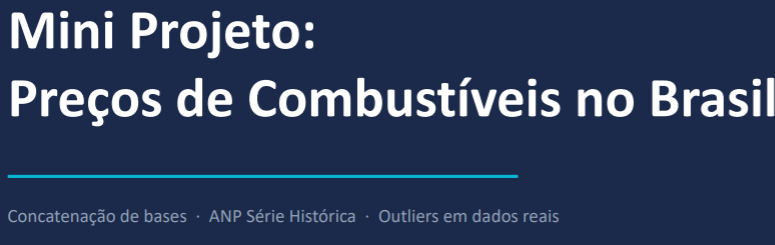

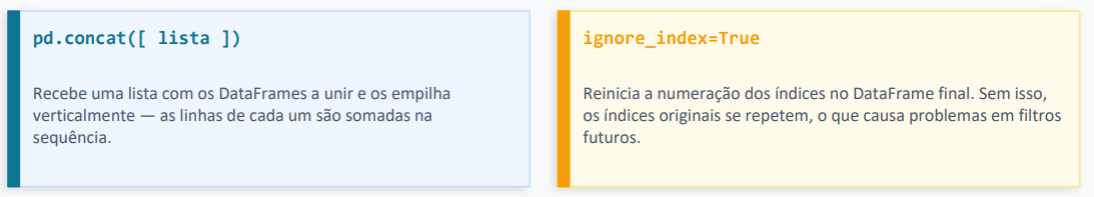

Link com a base de dados: https://dados.gov.br/dados/conjuntos-dados/serie-historica-de-precos-de-combustiveis-e-de-glp

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar dados arquivos baixados de cada semestre os arquivos CSV
df_2024_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
#df_2024_1.head()

df = pd.concat([df_2024_1, df_2024_2,df_2025_1,df_2025_2],ignore_index=True)  #ignora index dos arquivos e cria um novo index
print(df.shape) 
display(df.head(3))

#df.head()

(1908616, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA


In [6]:
# Preco medio praticado no periodo
df['Valor de Venda'].mean()

np.float64(5.448149402498984)

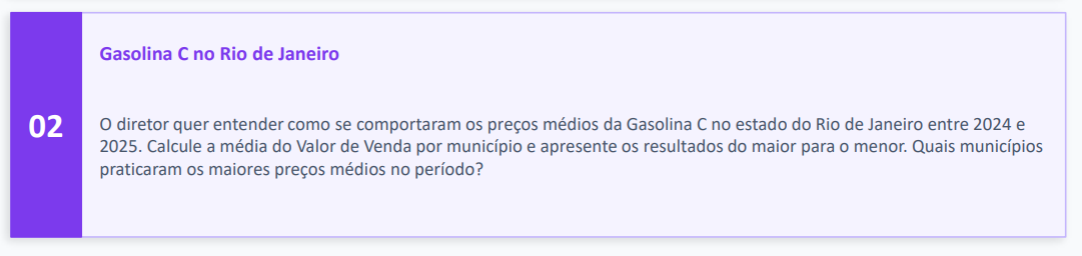

In [11]:
df_gas_rj = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]

In [19]:
df_munic_rj_gas = df_gas_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index()
df_munic_rj_gas.sort_values(by='Valor de Venda', ascending=False)
df_munic_rj_gas

,Municipio,Valor de Venda
0,ANGRA DOS REIS,6.265365
1,ARARUAMA,5.886346
2,BARRA DO PIRAI,6.153533
3,BARRA MANSA,5.895687
4,BELFORD ROXO,5.468756
5,CABO FRIO,5.992132
6,CAMPOS DOS GOYTACAZES,6.139322
7,DUQUE DE CAXIAS,5.583899
8,ITABORAI,5.605698
9,ITAGUAI,5.602390


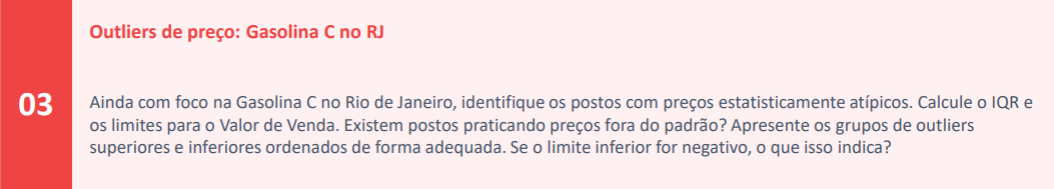

In [21]:
df_posto_rj = df_gas_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index()
df_posto_rj


,Revenda,Valor de Venda
0,3POSTO JULIO DE CASTILHO LIMITADA,5.698333
1,A C TRANCOZO M B COMBUSTÍVEIS LTDA,6.350000
2,A O LESSA LTDA,6.036250
3,A.P ITAIPU COMBUSTIVEIS LTDA,5.490000
4,A.P.J. ALCANTARA COMERCIO DE COMBUSTIVEIS LTDA,5.447143
...,...,...
682,VIA EXPRESSA AUTO POSTO LTDA,5.490000
683,VIA GÁS POSTO DE SERVIÇOS LTDA,5.588333
684,VICENTE SOUZA E CIA LTDA,6.290000
685,WEST POINT CAR POSTO DE ABASTECIMENTO LTDA,5.404783


calcular as medias num array para ver postos atipicos

In [ ]:
array_posto = df_posto_rj['Valor de Venda']
array_posto = np.arraydf_posto_rj['Valor de Venda']


array_posto.mean

limite_superior = 6.0

In [ ]:
df_outlier_posto_rj = df_posto_rj.loc[df_posto_rj['Valor de Venda'] > limite_superior]
df_outlier_posto_rj


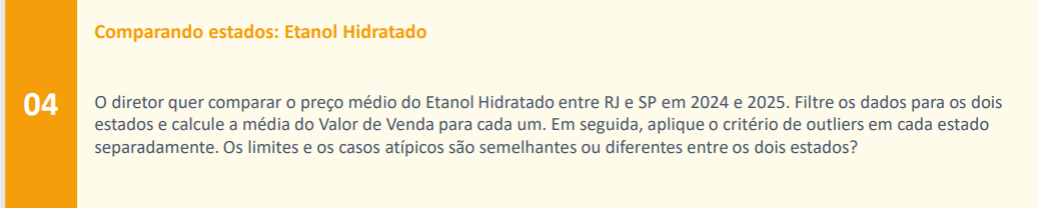

In [36]:
df_munic_rj = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]
df_munic_rj.head(3)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
2309,SE,RJ,RIO DE JANEIRO,POSTO DE COMBUSTIVEIS CANDIDO BENICIO LTDA,08.833.560/0001-39,RUA CANDIDO BENICIO,2742,NaN,PRACA SECA,22733-001,GASOLINA,02/01/2024,5.29,NaN,R$ / litro,VIBRA
2313,SE,RJ,RIO DE JANEIRO,POSTO E GARAGEM DOM HELDER CAMARA LTDA,04.802.584/0001-70,AVENIDA DOM HELDER CAMARA,4539,NaN,DEL CASTILHO,20771-000,GASOLINA,02/01/2024,5.69,NaN,R$ / litro,RAIZEN
2319,SE,RJ,RIO DE JANEIRO,POSTO DE GASOLINA ALTO ASTRAL DO MEIER LTDA,08.408.393/0001-89,RUA MEDINA,137,NaN,MEIER,20735-130,GASOLINA,02/01/2024,5.19,NaN,R$ / litro,BRANCA


In [47]:
df_bairro_rj = df_munic_rj.groupby('Bairro')['Valor de Venda'].mean().reset_index()
df_bairro_rj.sort_values(by='Valor de Venda', ascending=False)
df_bairro_rj.head(5)
#print('AAAAAAAAAAAAAAAAAA')


,Bairro,Valor de Venda
0,ANCHIETA,5.504286
1,ANDARAI,5.490000
2,ANDARAÍ,5.340000
3,ANIL,5.156667
4,BANGU,5.487500


In [43]:
df_bairro_rj

,Bairro,Valor de Venda
0,ANCHIETA,5.504286
1,ANDARAI,5.490000
2,ANDARAÍ,5.340000
3,ANIL,5.156667
4,BANGU,5.487500
...,...,...
66,TURIACU,5.504286
67,VASCO DA GAMA,5.684737
68,VICENTE DE CARVALHO,5.470000
69,VILA DA PENHA,5.445556
